### Imports

In [40]:
import math
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

from color_utils import srgb_to_oklab, oklab_to_srgb, oklab_dist
from file_utils import get_image
from image_utils import Sprite, get_color_positions

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load sprite

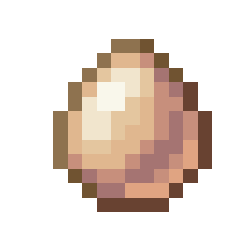

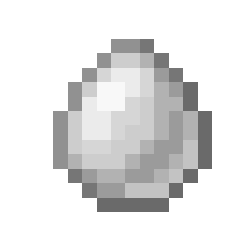

In [44]:
# img = get_image("asve", "apple.png")
# img = get_image("caverns_and_chasms", "music_disc_copy.png")
# img = get_image("vanilla", "raw_copper.png")
# img = get_image("vanilla", "amethyst_shard.png")
# img = get_image("scratch", "snake_test.png")
# img = get_image("create", "blaze_cake.png")
# img = get_image("reimagined", "golden_apple.png")
# img = get_image("reimagined", "egg.png")
# img = get_image("asve", "raw_gold.png")

NAMESPACE = "reimagined"
PATH = "egg.png"

#NAMESPACE = "vanilla"
#PATH = "raw_copper.png"

SPRITE = Sprite(get_image(NAMESPACE, PATH))

%matplotlib inline
SPRITE.display()
SPRITE.display_l()

In [42]:
palette = SPRITE.get_palette()

print(palette.keys())

graph = SPRITE.compute_connectivities(
    adj_multiplier=6.0,
    contour_multplier=4.0,
    similarity_multiplier=2.0
)
SPRITE.cull_connectivities(threshold=50)

print(graph.nodes)

dict_keys([(np.float64(0.4110821566501861), np.float64(-0.05188492984012726), np.float64(0.007856157845955447)), (np.float64(0.4580137896608609), np.float64(0.08293164533072636), np.float64(0.06758490215394286)), (np.float64(0.5944765656294959), np.float64(-0.07269906361349839), np.float64(0.01098994315599506)), (np.float64(0.5143236753412138), np.float64(-0.06673057338705539), np.float64(0.00907576920090725)), (np.float64(0.563746730484696), np.float64(0.027066782103381933), np.float64(0.07688460599408961)), (np.float64(0.6978599182806529), np.float64(0.11302796543852152), np.float64(0.0953873485585577)), (np.float64(0.7799386859383869), np.float64(0.10296564862062897), np.float64(0.0691928246622778)), (np.float64(0.606391115278271), np.float64(0.11178919713408314), np.float64(0.09587048146296055)), (np.float64(0.7169515209427177), np.float64(-0.10941614307541603), np.float64(0.0206856757851855)), (np.float64(0.8667417528895569), np.float64(0.05935509827952385), np.float64(0.038053362

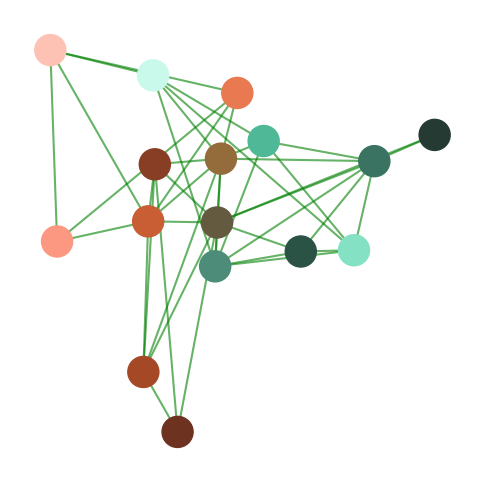

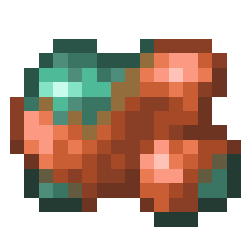

In [43]:
import networkx as nx

fig, ax = plt.subplots(figsize=(6, 6))
pos = nx.kamada_kawai_layout(graph)

# Create a node colors list from color groups
node_colors = []
for node in graph.nodes:
    ok_l, ok_a, ok_b = node
    r, g, b = oklab_to_srgb(np.asarray([ok_l, ok_a, ok_b]))
    node_colors.append(f"#{r:02X}{g:02X}{b:02X}")

# Draw all nodes at once with their respective colors
nx.draw_networkx_nodes(
    graph, pos,
    node_size=500,
    node_color=node_colors,
    ax=ax
)

# Separate relevant and irrelevant edges
relevant_edges = [(u, v) for (u, v) in graph.edges if graph.edges[u, v]["weight"] >= 40]
irrelevant_edges = [(u, v) for (u, v) in graph.edges if not graph.edges[u, v]["weight"] >= 40]

# Draw relevant edges in green
if relevant_edges:
    nx.draw_networkx_edges(
        graph, pos,
        edgelist=relevant_edges,
        edge_color='green',
        width=1.5,
        alpha=0.6,
        ax=ax
    )

# Draw irrelevant edges in red
if irrelevant_edges:
    nx.draw_networkx_edges(
        graph, pos,
        edgelist=irrelevant_edges,
        edge_color='red',
        width=1.5,
        alpha=0.6,
        ax=ax
    )

ax.set_axis_off()
SPRITE.display()
# plt.close(fig)